# How are in demand skills trending for the role of Data Analysts vs Data Scientist 

## Methodology 
1) Aggregate skills count monthly
2) Reanalyse based on percentage of total job postings
3) Plot and compare the monthly skill demand of Data Analyst and Data Scientist 

In [89]:
#importing libraries 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import ast
import seaborn as sns
from datasets import load_dataset
from matplotlib.lines import Line2D


#Loading the data 
dataset=load_dataset("lukebarousse/data_jobs")
df=dataset["train"].to_pandas()
df_work=df.copy()


#Data cleanup 
# Converting job_posted_date to datetime object 
df_work["job_posted_date"]=pd.to_datetime(df_work["job_posted_date"])
# Converting job_skills to list 
df_work["job_skills"]=df_work.job_skills.apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
df_Poland=df_work[df_work.job_country=="Poland"].copy().reset_index()
df_Poland
df_Poland.drop(columns="index", inplace=True)

In [3]:
df_Poland["job_posted_month_no"]=df_Poland.job_posted_date.dt.month
df_Poland

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
0,Data Analyst,Data Analyst,"Warsaw, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-10-16 13:36:54,False,False,Poland,NaN,NaN,NaN,Glovo,"[sql, python, r, redshift, pandas, excel, look...","{'analyst_tools': ['excel', 'looker', 'tableau...",10
1,Data Engineer,Chapter Lead Data Engineers Poland,"Wrocław, Poland",via Trabajo.org,Full-time,False,Poland,2023-01-16 13:58:03,False,False,Poland,NaN,NaN,NaN,Volvo Group,"[azure, excel, unity]","{'analyst_tools': ['excel'], 'cloud': ['azure'...",1
2,Data Engineer,Data Engineer,"Kraków, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-06-04 14:12:20,True,False,Poland,NaN,NaN,NaN,SII Group,"[sql, shell, python, aws]","{'cloud': ['aws'], 'programming': ['sql', 'she...",6
3,Data Scientist,Mid/ Senior Data Scientist with NLP,Anywhere,via LinkedIn,Full-time,True,Poland,2023-12-21 13:10:55,False,False,Poland,NaN,NaN,NaN,Trans.eu Group,"[python, sql, snowflake, aws, scikit-learn, ke...","{'cloud': ['snowflake', 'aws'], 'libraries': [...",12
4,Software Engineer,Data Platform Software Engineer,"Warsaw, Poland",via Adzuna.pl,Full-time,False,Poland,2023-06-23 13:58:41,True,False,Poland,NaN,NaN,NaN,IBM,"[python, sql, shell, ibm cloud, linux]","{'cloud': ['ibm cloud'], 'os': ['linux'], 'pro...",6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14788,Data Scientist,Data Scientist,"Warsaw, Poland",via Trabajo.org,Full-time,False,Poland,2023-01-13 06:41:55,False,False,Poland,NaN,NaN,NaN,Citi,"[python, r]","{'programming': ['python', 'r']}",1
14789,Senior Data Analyst,VP - Institutional Credit Management - Lending...,"Warsaw, Poland",via Trabajo.org,Full-time,False,Poland,2023-01-13 06:41:53,True,False,Poland,NaN,NaN,NaN,Citi,NaN,NaN,1
14790,Software Engineer,Integration Analyst,"Łódź, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-04-26 06:24:52,False,False,Poland,NaN,NaN,NaN,Team Quest,"[sql, oracle, aws, sap, atlassian]","{'analyst_tools': ['sap'], 'cloud': ['oracle',...",4
14791,Machine Learning Engineer,Senior Machine Learning Engineer,"Warsaw, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-06-07 06:18:29,False,False,Poland,NaN,NaN,NaN,Digital Hub Warsaw At Bayer,"[python, aws, gcp, azure, tensorflow, pytorch,...","{'cloud': ['aws', 'gcp', 'azure'], 'libraries'...",6


In [4]:
df_exploded=df_Poland.explode("job_skills")
df_DA_PL=df_exploded[df_exploded.job_title_short=="Data Analyst"]
df_DS_PL=df_exploded[df_exploded.job_title_short=="Data Scientist"]

In [5]:
agg_DA=df_DA_PL.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0)
agg_DS=df_DS_PL.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0)

In [6]:
agg_DA.loc["Total"]=agg_DA.sum()
agg_DA

job_skills,airflow,alteryx,angular,ansible,asana,asp.net,asp.net core,assembly,atlassian,aws,...,vba,visio,visual basic,vue,watson,webex,windows,wire,word,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,10,19,1,0,0,0,0,0,0,42,...,32,6,3,0,0,1,13,0,22,3
2,15,7,0,0,0,0,0,1,2,25,...,42,4,2,0,0,0,18,0,20,3
3,7,11,1,0,0,0,0,0,0,20,...,29,6,2,1,0,2,18,0,19,3
4,11,2,1,0,0,0,0,0,0,26,...,24,2,4,0,0,0,10,0,19,1
5,1,5,0,0,0,0,0,0,0,21,...,17,2,2,0,0,0,5,0,12,0
6,7,4,0,0,0,0,0,0,0,8,...,16,5,1,0,0,0,5,0,14,1
7,6,10,0,0,0,0,0,0,0,14,...,18,2,0,0,0,1,3,0,12,0
8,3,8,0,1,0,1,1,1,0,11,...,12,3,1,0,1,0,3,0,12,0
9,3,2,0,0,0,0,0,1,1,9,...,7,0,0,0,0,0,2,1,5,0


In [7]:
agg_DS.loc["Total"]=agg_DS.sum()
agg_DS

job_skills,airflow,airtable,alteryx,angular,ansible,arch,asp.net,asp.net core,assembly,atlassian,...,vmware,vue.js,watson,webex,windows,wire,word,wrike,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,14,0,11,0,1,1,0,0,0,0,...,1,0,0,0,11,0,6,0,1,1
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,2,0,0,0
3,9,0,5,0,0,0,0,0,0,0,...,1,0,0,1,5,0,3,0,0,0
4,6,1,1,0,0,0,0,0,0,0,...,0,0,0,0,5,1,1,0,0,0
5,7,0,0,0,1,0,0,0,0,0,...,0,0,1,0,3,0,3,0,0,1
6,1,0,1,2,0,0,0,0,0,0,...,0,0,4,0,3,0,0,2,0,2
7,3,0,0,1,0,0,0,0,0,0,...,0,0,0,0,5,0,3,0,0,0
8,3,0,3,2,1,0,3,3,0,1,...,1,1,0,0,7,0,2,0,0,0
9,1,0,4,0,0,1,0,0,0,0,...,0,0,0,0,6,0,2,0,0,0


In [8]:
agg_DA.sort_values(by="Total", axis=1, ascending=False, inplace=True)
agg_DA

job_skills,sql,excel,python,tableau,power bi,sap,r,azure,sas,vba,...,ibm cloud,groovy,react.js,redis,ggplot2,flutter,f#,couchbase,clickup,nltk
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,233,183,122,114,102,52,52,52,34,32,...,1,0,0,1,0,0,0,1,0,0
2,210,141,124,87,92,52,53,33,44,42,...,0,0,0,0,0,0,0,0,0,0
3,168,144,106,84,73,30,40,28,40,29,...,0,0,0,0,0,0,0,0,0,0
4,132,102,76,72,60,32,23,21,8,24,...,0,0,0,0,1,1,1,0,0,0
5,134,96,87,48,46,25,25,25,4,17,...,0,0,0,0,0,0,0,0,0,0
6,89,90,56,40,43,28,23,4,16,16,...,0,1,0,0,0,0,0,0,0,0
7,127,106,86,63,51,32,21,12,20,18,...,0,0,0,0,0,0,0,0,0,0
8,152,119,75,42,68,42,24,26,32,12,...,0,0,1,0,0,0,0,0,0,0
9,71,48,47,30,21,15,14,12,6,7,...,0,0,0,0,0,0,0,0,0,0


In [9]:
agg_DS.sort_values(by="Total", axis=1, ascending=False, inplace=True)
agg_DS

job_skills,python,sql,r,azure,aws,spark,tableau,git,excel,pandas,...,selenium,splunk,couchbase,flutter,pulumi,ssrs,dart,crystal,couchdb,elixir
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,185,146,69,55,62,59,28,38,36,34,...,0,0,1,1,0,1,0,0,0,0
2,89,84,40,32,22,26,18,18,25,17,...,0,0,0,0,0,0,1,0,0,0
3,106,88,44,36,27,28,20,17,25,17,...,0,0,0,0,0,0,0,1,1,0
4,70,64,29,26,20,14,21,20,19,14,...,0,1,0,0,1,0,0,0,0,1
5,53,53,19,13,16,16,19,12,13,10,...,0,0,0,0,0,0,0,0,0,0
6,85,86,35,20,23,23,22,17,15,13,...,0,0,0,0,0,0,0,0,0,0
7,92,91,39,19,22,19,23,11,16,13,...,0,0,0,0,0,0,0,0,0,0
8,114,104,38,41,30,19,31,17,11,16,...,1,0,0,0,0,0,0,0,0,0
9,59,47,16,17,13,15,10,17,4,14,...,0,0,0,0,0,0,0,0,0,0


In [118]:
Total_DA=df_Poland[df_Poland.job_title_short=="Data Analyst"].groupby("job_posted_month_no").size()
Total_DS=df_Poland[df_Poland.job_title_short=="Data Scientist"].groupby("job_posted_month_no").size()

In [119]:
Total_DA

job_posted_month_no
1     505
2     395
3     336
4     283
5     245
6     209
7     258
8     310
9     142
10    174
11    167
12    148
dtype: int64

In [120]:
Total_DS

job_posted_month_no
1     313
2     160
3     174
4     140
5     107
6     132
7     141
8     173
9      89
10     98
11     95
12     91
dtype: int64

In [121]:
agg_DA_perc=agg_DA.div(Total_DA/100, axis=0)
agg_DS_perc=agg_DS.div(Total_DS, axis=0)*100

In [122]:
agg_DA
agg_DA_perc

job_skills,sql,excel,python,tableau,power bi,sap,r,azure,sas,vba,...,ibm cloud,groovy,react.js,redis,ggplot2,flutter,f#,couchbase,clickup,nltk
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,46.138614,36.237624,24.158416,22.574257,20.198020,10.297030,10.297030,10.297030,6.732673,6.336634,...,0.19802,0.000000,0.000000,0.19802,0.000000,0.000000,0.000000,0.19802,0.000000,0.000000
2,53.164557,35.696203,31.392405,22.025316,23.291139,13.164557,13.417722,8.354430,11.139241,10.632911,...,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,50.000000,42.857143,31.547619,25.000000,21.726190,8.928571,11.904762,8.333333,11.904762,8.630952,...,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,46.643110,36.042403,26.855124,25.441696,21.201413,11.307420,8.127208,7.420495,2.826855,8.480565,...,0.00000,0.000000,0.000000,0.00000,0.353357,0.353357,0.353357,0.00000,0.000000,0.000000
5,54.693878,39.183673,35.510204,19.591837,18.775510,10.204082,10.204082,10.204082,1.632653,6.938776,...,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
6,42.583732,43.062201,26.794258,19.138756,20.574163,13.397129,11.004785,1.913876,7.655502,7.655502,...,0.00000,0.478469,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
7,49.224806,41.085271,33.333333,24.418605,19.767442,12.403101,8.139535,4.651163,7.751938,6.976744,...,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
8,49.032258,38.387097,24.193548,13.548387,21.935484,13.548387,7.741935,8.387097,10.322581,3.870968,...,0.00000,0.000000,0.322581,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
9,50.000000,33.802817,33.098592,21.126761,14.788732,10.563380,9.859155,8.450704,4.225352,4.929577,...,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [123]:
agg_DS_perc

job_skills,python,sql,r,azure,aws,spark,tableau,git,excel,pandas,...,selenium,splunk,couchbase,flutter,pulumi,ssrs,dart,crystal,couchdb,elixir
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,59.105431,46.645367,22.044728,17.571885,19.808307,18.849840,8.945687,12.140575,11.501597,10.862620,...,0.000000,0.000000,0.319489,0.319489,0.000000,0.319489,0.000,0.000000,0.000000,0.000000
2,55.625000,52.500000,25.000000,20.000000,13.750000,16.250000,11.250000,11.250000,15.625000,10.625000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.625,0.000000,0.000000,0.000000
3,60.919540,50.574713,25.287356,20.689655,15.517241,16.091954,11.494253,9.770115,14.367816,9.770115,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.574713,0.574713,0.000000
4,50.000000,45.714286,20.714286,18.571429,14.285714,10.000000,15.000000,14.285714,13.571429,10.000000,...,0.000000,0.714286,0.000000,0.000000,0.714286,0.000000,0.000,0.000000,0.000000,0.714286
5,49.532710,49.532710,17.757009,12.149533,14.953271,14.953271,17.757009,11.214953,12.149533,9.345794,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000
6,64.393939,65.151515,26.515152,15.151515,17.424242,17.424242,16.666667,12.878788,11.363636,9.848485,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000
7,65.248227,64.539007,27.659574,13.475177,15.602837,13.475177,16.312057,7.801418,11.347518,9.219858,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000
8,65.895954,60.115607,21.965318,23.699422,17.341040,10.982659,17.919075,9.826590,6.358382,9.248555,...,0.578035,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000
9,66.292135,52.808989,17.977528,19.101124,14.606742,16.853933,11.235955,19.101124,4.494382,15.730337,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000


In [124]:
top_5_DA=agg_DA_perc.iloc[:, :5].drop(index="Total")

In [125]:
top_5_DS=agg_DS_perc.iloc[:, :5].drop(index="Total")

In [126]:
top_5_DA=top_5_DA.reset_index()
top_5_DA["job_posted_month"]=top_5_DA["job_posted_month_no"].apply(lambda x: pd.to_datetime(x,format="%m"))
top_5_DA["job_posted_month"]=top_5_DA["job_posted_month"].dt.strftime("%b")
top_5_DA=top_5_DA.set_index("job_posted_month").drop(columns="job_posted_month_no")
top_5_DA

job_skills,sql,excel,python,tableau,power bi
job_posted_month,,,,,
Jan,46.138614,36.237624,24.158416,22.574257,20.198020
Feb,53.164557,35.696203,31.392405,22.025316,23.291139
Mar,50.000000,42.857143,31.547619,25.000000,21.726190
Apr,46.643110,36.042403,26.855124,25.441696,21.201413
May,54.693878,39.183673,35.510204,19.591837,18.775510
Jun,42.583732,43.062201,26.794258,19.138756,20.574163
Jul,49.224806,41.085271,33.333333,24.418605,19.767442
Aug,49.032258,38.387097,24.193548,13.548387,21.935484
Sep,50.000000,33.802817,33.098592,21.126761,14.788732


In [127]:
top_5_DS=top_5_DS.reset_index()
top_5_DS["job_posted_month"]=top_5_DS["job_posted_month_no"].apply(lambda x: pd.to_datetime(x,format="%m"))
top_5_DS["job_posted_month"]=top_5_DS["job_posted_month"].dt.strftime("%b")
top_5_DS=top_5_DS.set_index("job_posted_month").drop(columns="job_posted_month_no")
top_5_DS

job_skills,python,sql,r,azure,aws
job_posted_month,,,,,
Jan,59.105431,46.645367,22.044728,17.571885,19.808307
Feb,55.625000,52.500000,25.000000,20.000000,13.750000
Mar,60.919540,50.574713,25.287356,20.689655,15.517241
Apr,50.000000,45.714286,20.714286,18.571429,14.285714
May,49.532710,49.532710,17.757009,12.149533,14.953271
Jun,64.393939,65.151515,26.515152,15.151515,17.424242
Jul,65.248227,64.539007,27.659574,13.475177,15.602837
Aug,65.895954,60.115607,21.965318,23.699422,17.341040
Sep,66.292135,52.808989,17.977528,19.101124,14.606742


In [128]:
#top_5_DA=top_5_DA.drop(columns=["index"])
#top_5_DS=top_5_DS.drop(columns=["index"])

In [129]:
unique_skills_1=list(top_5_DA.columns)

unique_skills_2=list(top_5_DS.columns)


In [130]:
unique_skills=set(unique_skills_1+unique_skills_2)

In [131]:
unique_skills
colours=sns.color_palette("tab10", len(unique_skills))
skill_palette = dict(zip(unique_skills, colours))

In [132]:
skill_palette.keys()

dict_keys(['sql', 'excel', 'power bi', 'aws', 'python', 'azure', 'tableau', 'r'])

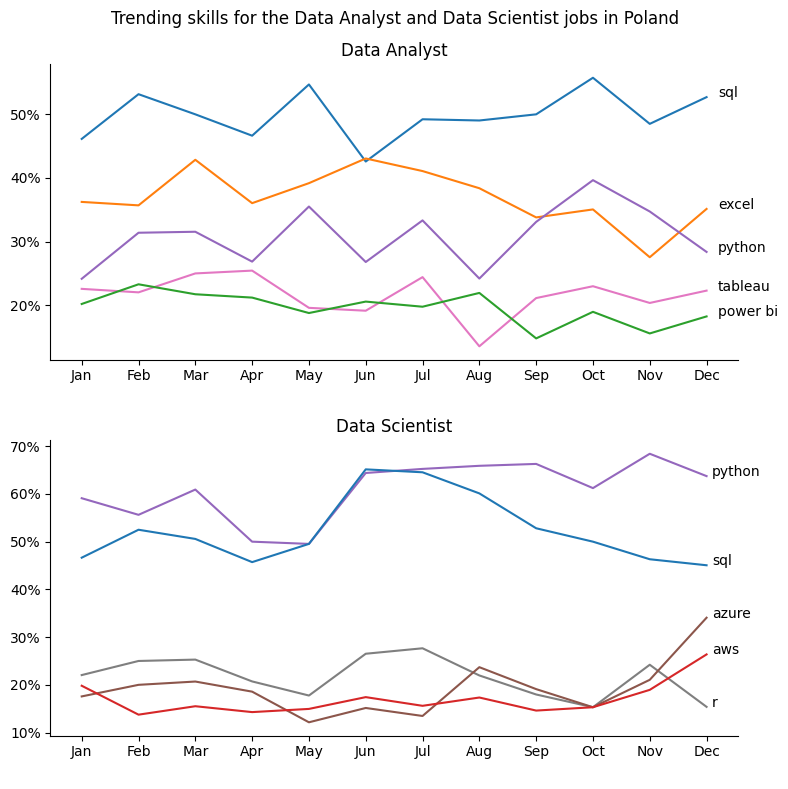

In [133]:
from matplotlib.ticker import PercentFormatter
fig, ax=plt.subplots(2,1, figsize=(8,8))
sns.lineplot(data=top_5_DA, ax=ax[0], dashes=False, palette=skill_palette, legend=False)
ax[0].set_title("Data Analyst")
ax[0].yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax[0].set_xlabel(" ")
sns.lineplot(data=top_5_DS, ax=ax[1], dashes=False, palette=skill_palette, legend=False)
ax[1].set_title("Data Scientist")
ax[1].yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax[1].set_xlabel(" ")

fig.suptitle("Trending skills for the Data Analyst and Data Scientist jobs in Poland")
sns.despine()

for i in range(5):
    ax[0].text(x=11.2,y=top_5_DA.iloc[-1,i], s=top_5_DA.columns[i])
    ax[1].text(x=11.1,y=top_5_DS.iloc[-1,i], s=top_5_DS.columns[i])
plt.tight_layout()
plt.show()